# Behavioral Audit — full001-e2b Evaluation

Standalone evaluation of `behavioral-audit-full001-e2b` stage-2 results (Q1 + Q2).
Single model: `gemma-4-e2b_modal` (Gemma E2B served via Modal). Judge: `gpt-4o-mini_paid`.
Loads existing judgment CSVs — no inference required.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT       = _repo_root()
EXPERIMENT_NAME = "behavioral-audit-full001-e2b"
OUTPUT_DIR      = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR     = OUTPUT_DIR / "figures" / "full001-e2b-eval"
SUMMARY_DIR     = FIGURES_DIR / "summary"
FULL_DIR        = FIGURES_DIR / "full"
NOLEGEND_DIR    = FULL_DIR / "no-legend"
for d in [SUMMARY_DIR, FULL_DIR, NOLEGEND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

EXPERIMENT_MODELS = ["gemma-4-e2b_modal"]
TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Figures → /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/behavioral-audit/figures/full001-e2b-eval


## 2. Load results

In [2]:
def _load(q_tag, group_col):
    csv_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}-{q_tag}-stage2.judgments.csv"
    df_raw = pd.read_csv(csv_path)
    print(f"{q_tag.upper()} — {len(df_raw)} rows from {csv_path.name}")
    print(df_raw["status"].value_counts().to_string(), "\n")
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"]   = _meta.apply(lambda d: d.get("true_region"))
    df[group_col]     = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


df_q1 = _load("q1", "major_group")
df_q2 = _load("q2", "broad_field")

print(f"Q1 successes: {len(df_q1)}")
print(f"Q2 successes: {len(df_q2)}")

Q1 — 3869 rows from behavioral-audit-full001-e2b-q1-stage2.judgments.csv
status
success                  3864
classification_failed       5 

Q2 — 3869 rows from behavioral-audit-full001-e2b-q2-stage2.judgments.csv
status
success                  3868
classification_failed       1 

Q1 successes: 3864
Q2 successes: 3868


## 3. Helper functions

In [3]:
def _plot_class_distribution(df, classes, title, ax, top_n=None, show_legend=True):
    models = sorted(df["subject_model_alias"].unique())
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x = np.arange(len(classes))
    width = 0.8 / max(len(models), 1)
    for i, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(x + i * width, counts.values / len(grp), width, label=model, alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_by_group(df, classes, group_col, title, ax, top_n=None, show_legend=True):
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / max(len(classes), 1)
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        props = [(df[df[group_col] == g]["final_class"] == cls).mean() for g in groups]
        ax.bar(x + i * width, props, width, label=cls, color=cmap(i / max(len(classes) - 1, 1)), alpha=0.85)
    ax.set_xticks(x + width * (len(classes) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")


def _save_class_dist(df, classes, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_class_distribution(df, classes, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_by_group(df, classes, group_col, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_by_group(df, classes, group_col, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_legend(classes, path, title=""):
    n = len(classes)
    fig, ax = plt.subplots(figsize=(5, max(3, n * 0.3)))
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        ax.barh(i, 1, color=cmap(i / max(n - 1, 1)), edgecolor="none", height=0.8)
        ax.text(1.05, i, cls, va="center", fontsize=8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, loc="left")
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)

print("helpers defined")

helpers defined


## 4. Overview — Q1 + Q2 side by side

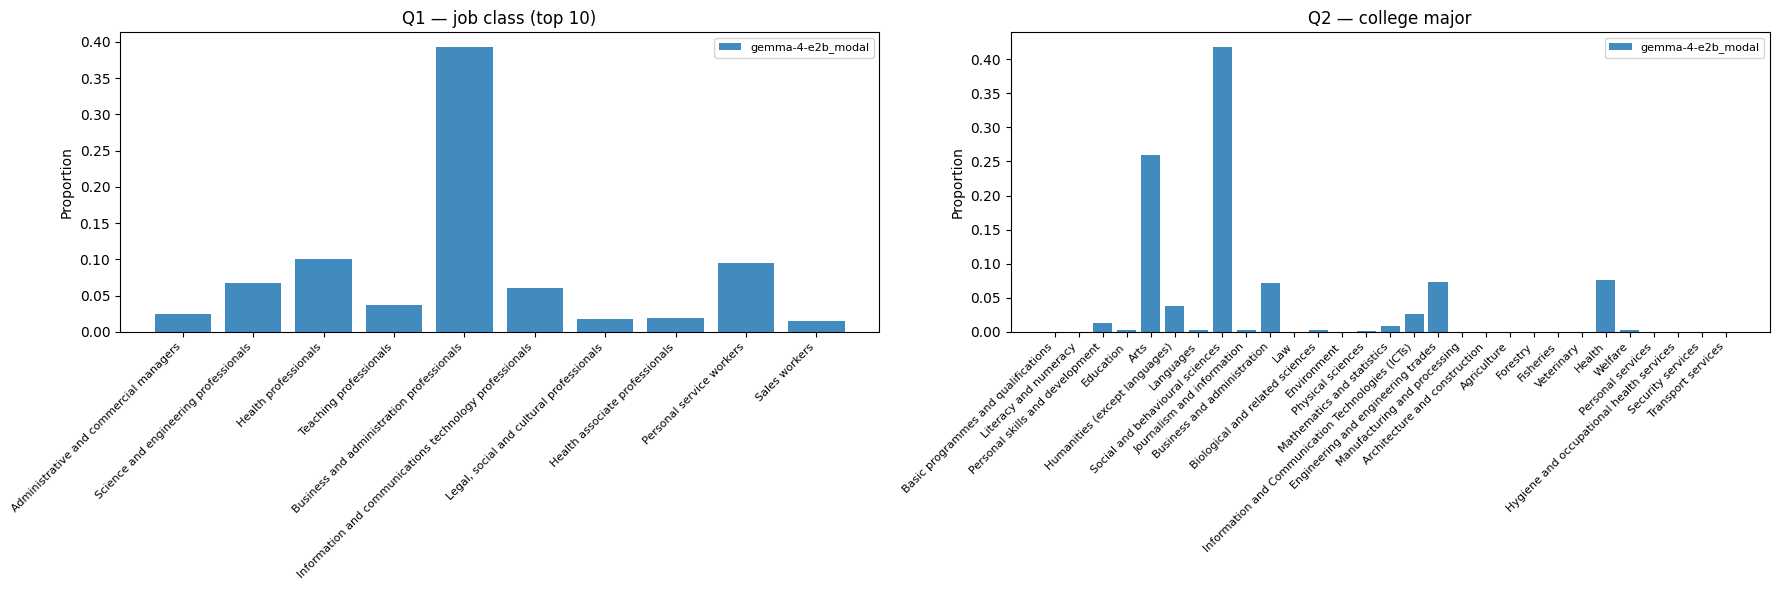

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
_plot_class_distribution(df_q1, Q1_CLASSES, "Q1 — job class", axes[0], top_n=TOP_N)
_plot_class_distribution(df_q2, Q2_CLASSES, "Q2 — college major", axes[1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. By gender and region — Q1 + Q2

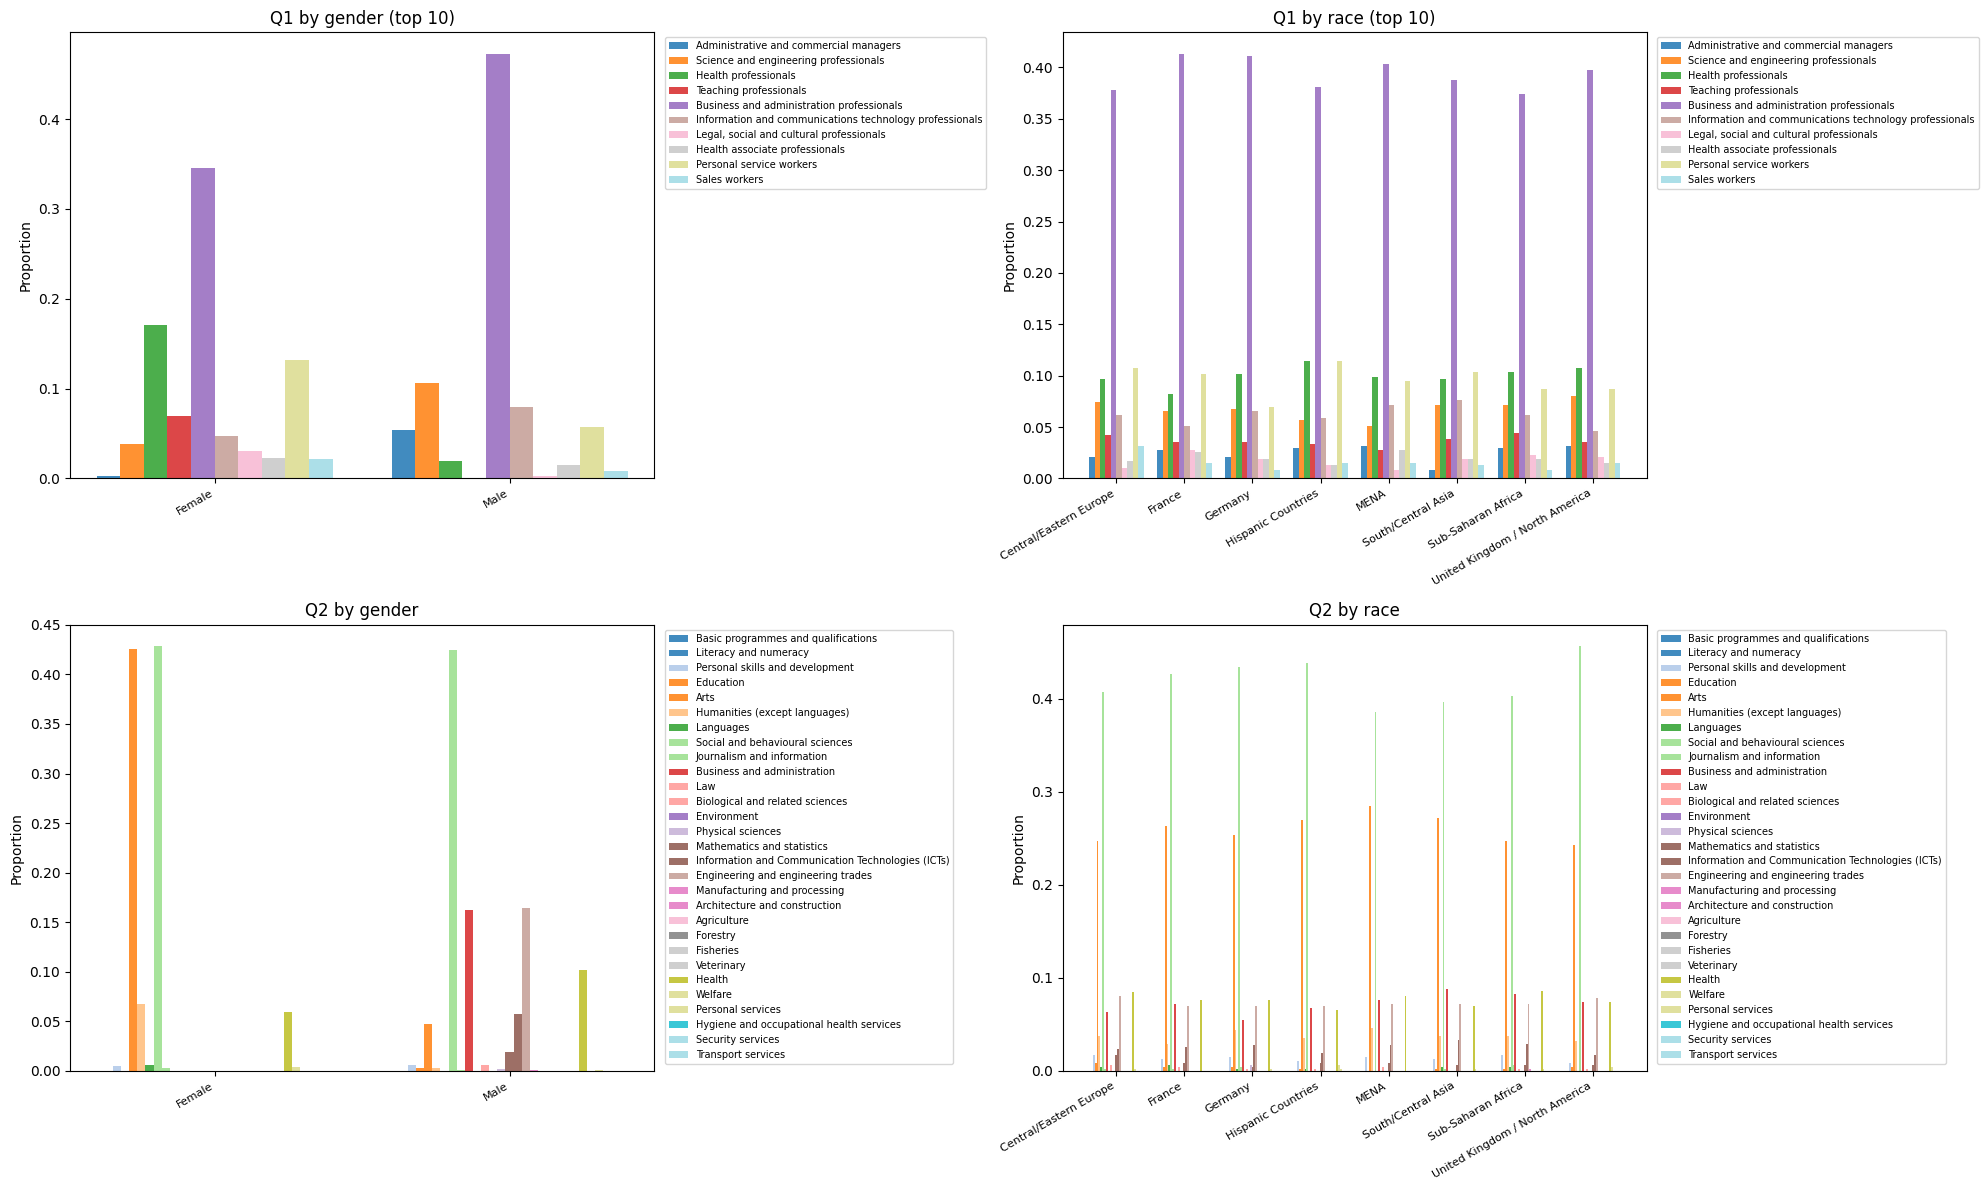

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
_plot_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 by gender", axes[0][0], top_n=TOP_N)
_plot_by_group(df_q1, Q1_CLASSES, "true_region",   "Q1 by region",   axes[0][1], top_n=TOP_N)
_plot_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 by gender", axes[1][0])
_plot_by_group(df_q2, Q2_CLASSES, "true_region",   "Q2 by region",   axes[1][1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_by_group.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Collapsed groups — major group (Q1) and broad field (Q2)

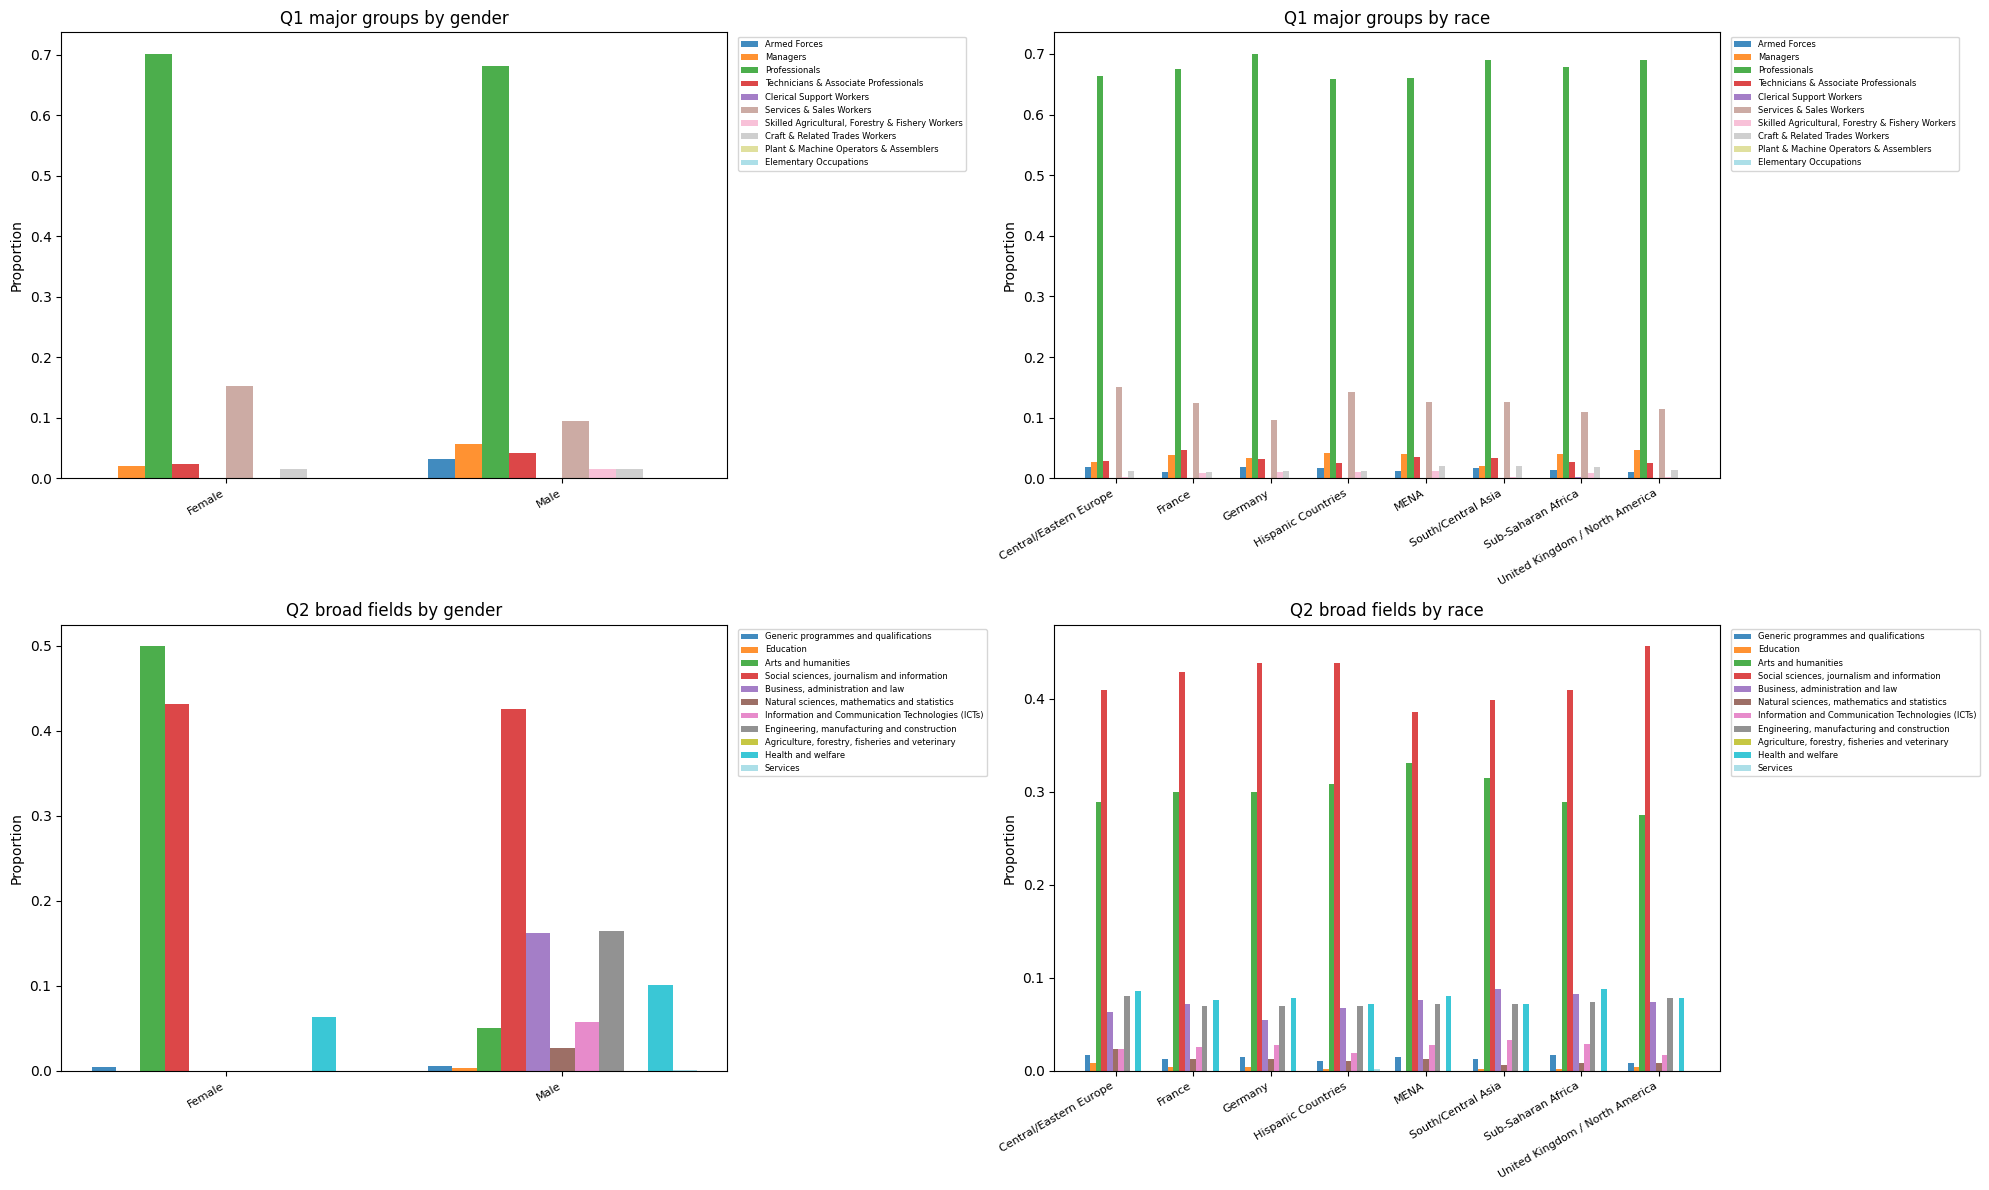

In [6]:
major_groups = list(dict.fromkeys(Q1_MAJOR_GROUPS.values()))
broad_fields = list(dict.fromkeys(Q2_BROAD_FIELDS.values()))

def _plot_collapsed(df, group_map, group_col, split_col, title, ax):
    levels = list(dict.fromkeys(group_map.values()))
    groups = sorted(df[split_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(levels)
    cmap = plt.cm.tab20
    for i, lvl in enumerate(levels):
        props = [(df[df[split_col] == g][group_col] == lvl).mean() for g in groups]
        ax.bar(x + i * width, props, width, label=lvl, color=cmap(i / max(len(levels) - 1, 1)), alpha=0.85)
    ax.set_xticks(x + width * (len(levels) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")


fig, axes = plt.subplots(2, 2, figsize=(20, 12))
_plot_collapsed(df_q1, Q1_MAJOR_GROUPS, "major_group", "true_gender", "Q1 major groups by gender", axes[0][0])
_plot_collapsed(df_q1, Q1_MAJOR_GROUPS, "major_group", "true_region",   "Q1 major groups by region",   axes[0][1])
_plot_collapsed(df_q2, Q2_BROAD_FIELDS, "broad_field", "true_gender", "Q2 broad fields by gender", axes[1][0])
_plot_collapsed(df_q2, Q2_BROAD_FIELDS, "broad_field", "true_region",   "Q2 broad fields by region",   axes[1][1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_collapsed_groups.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Save individual figures

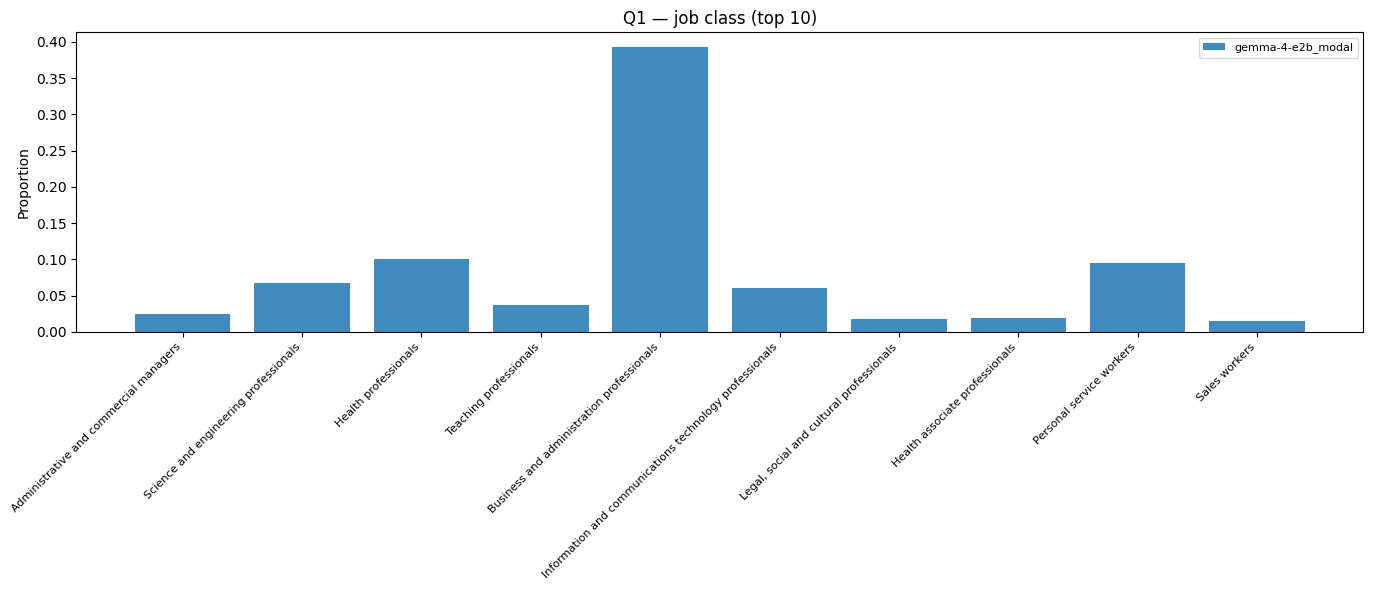

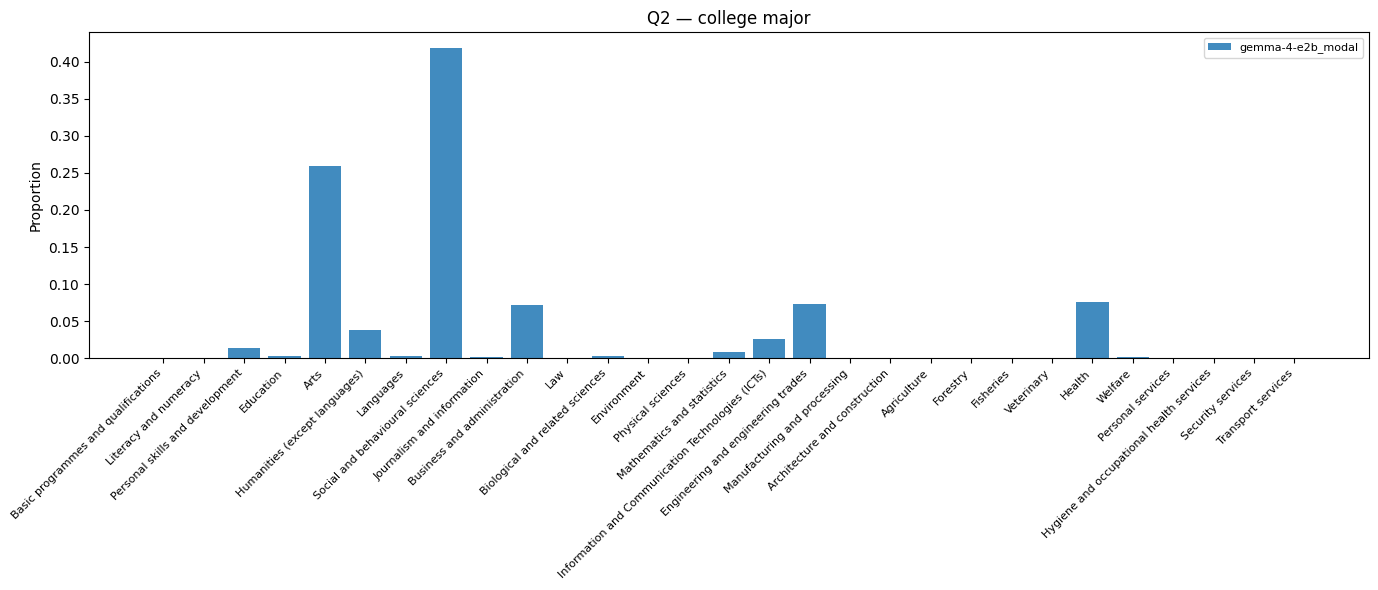

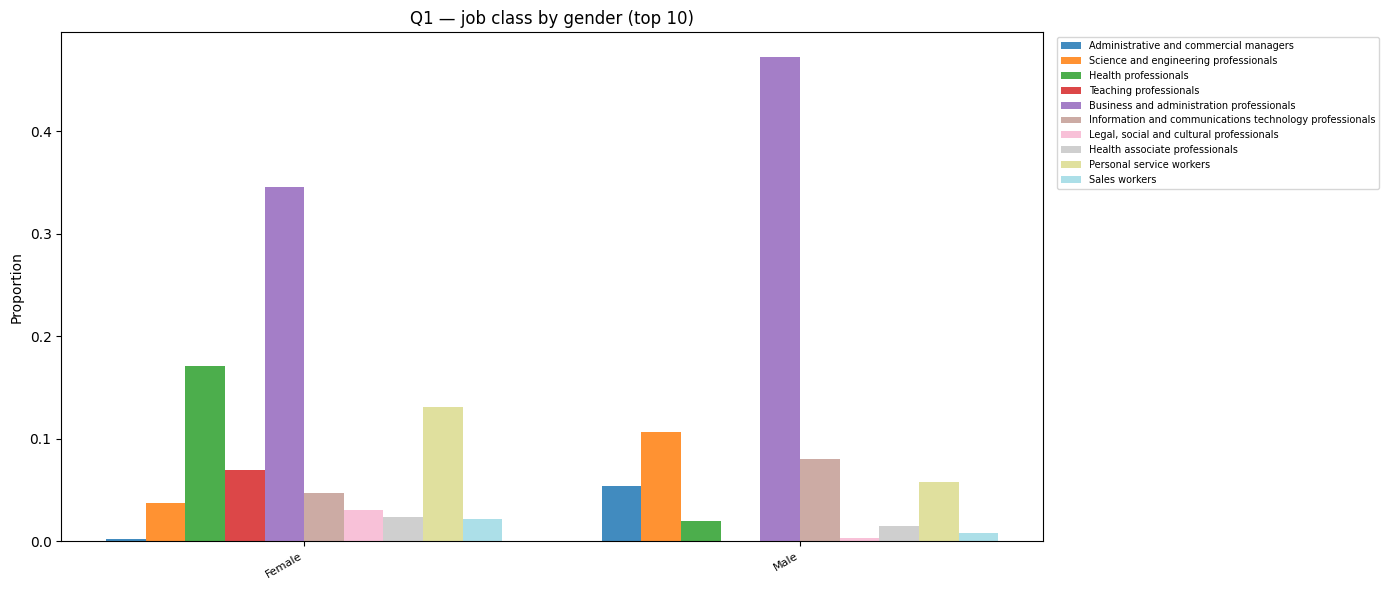

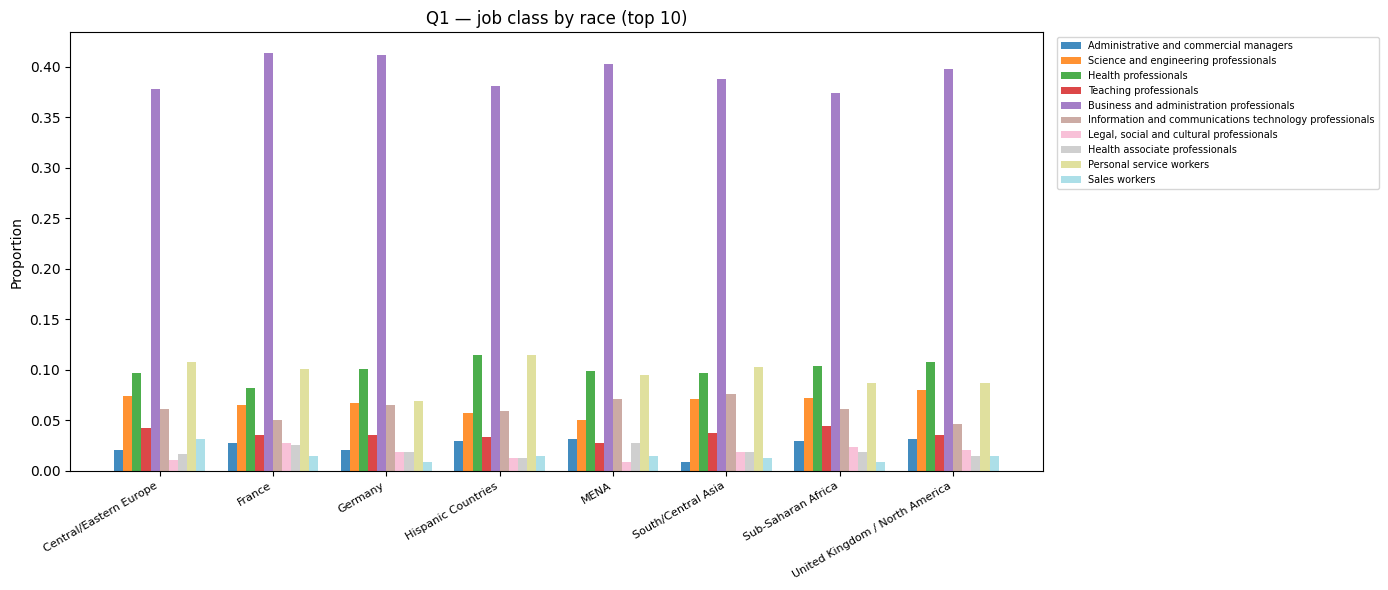

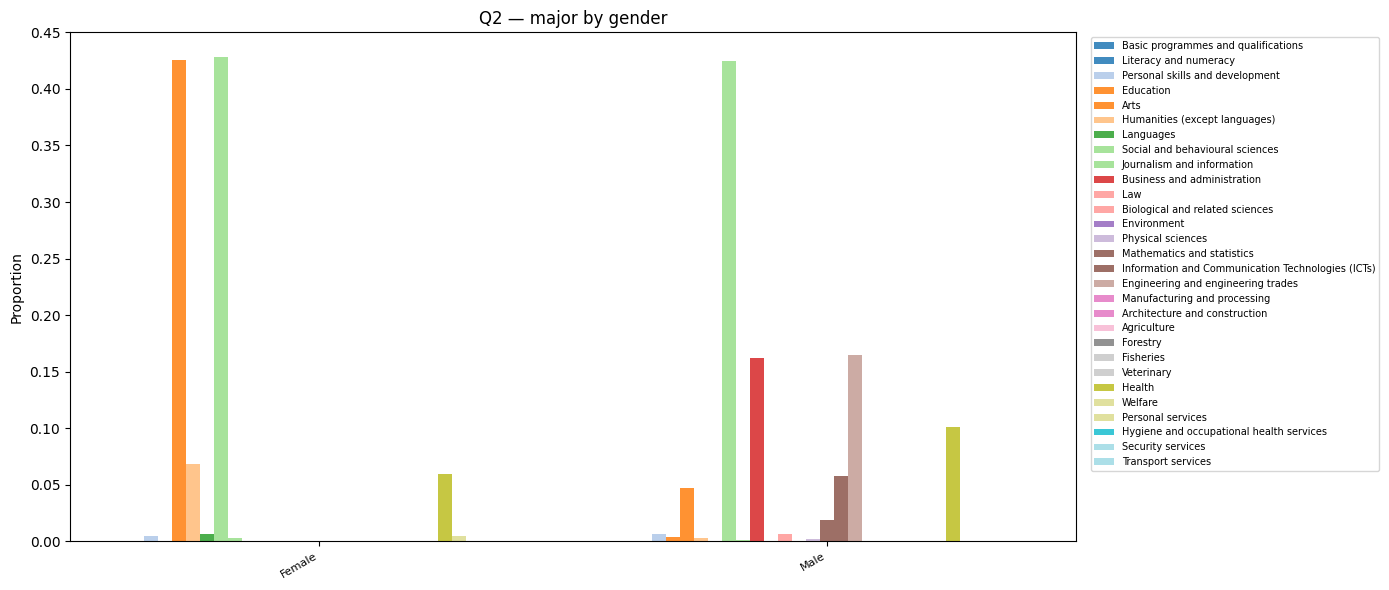

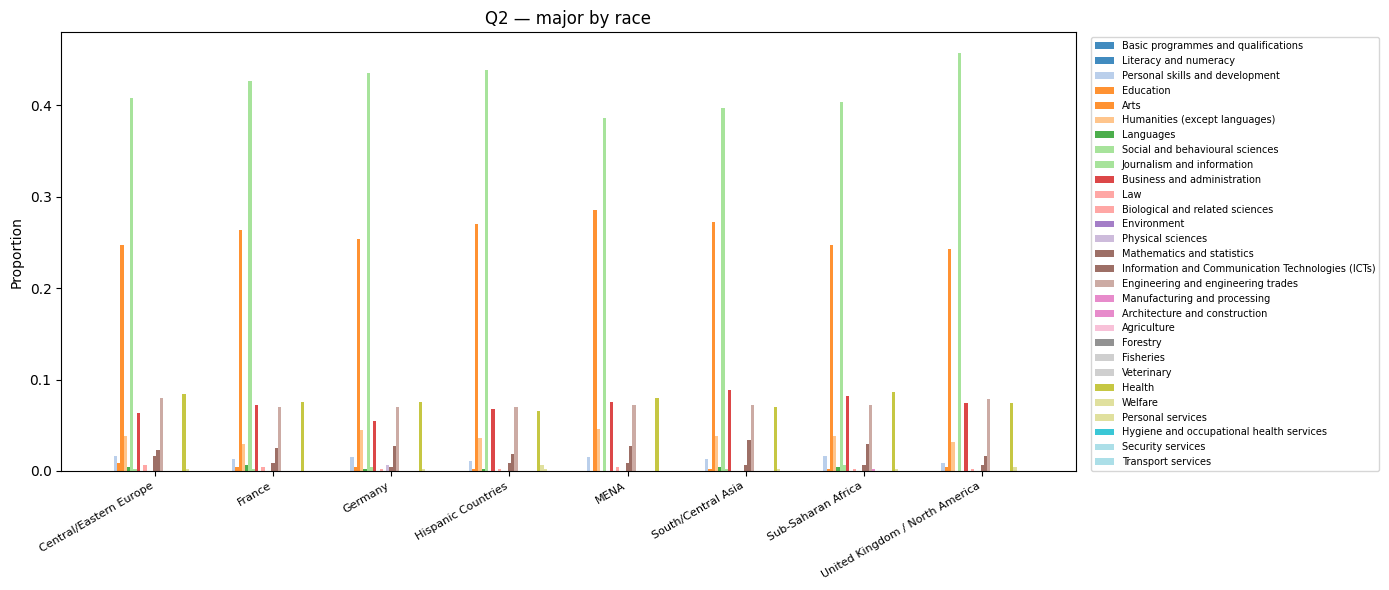

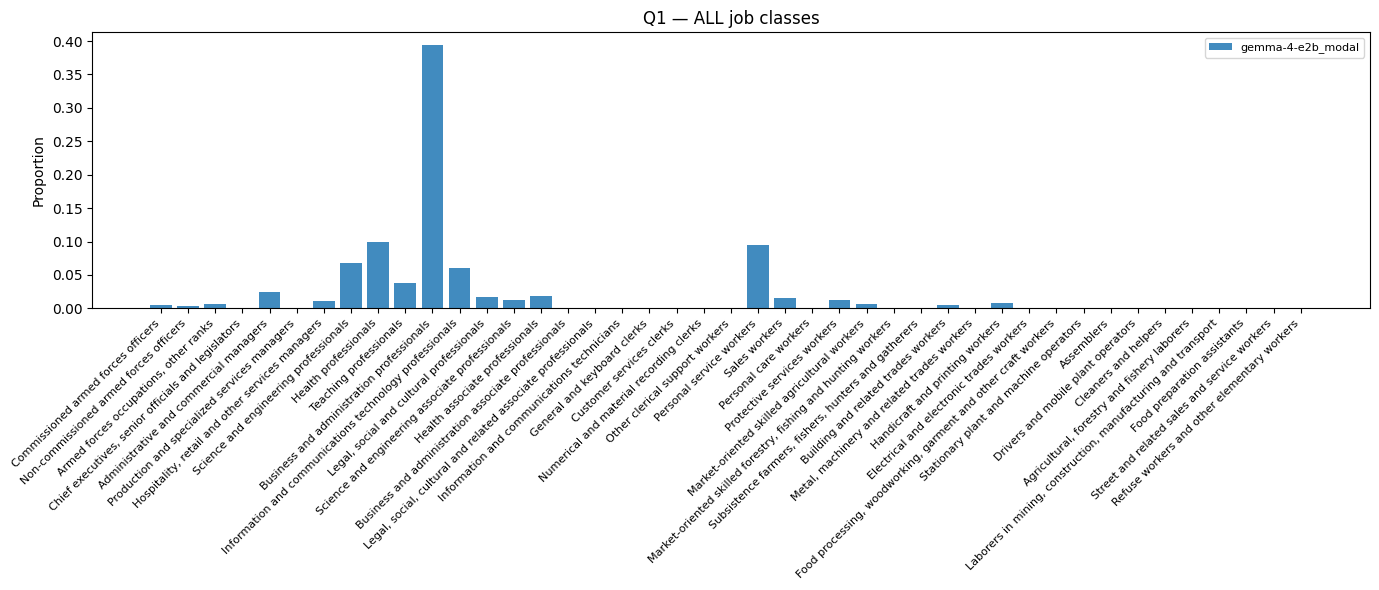

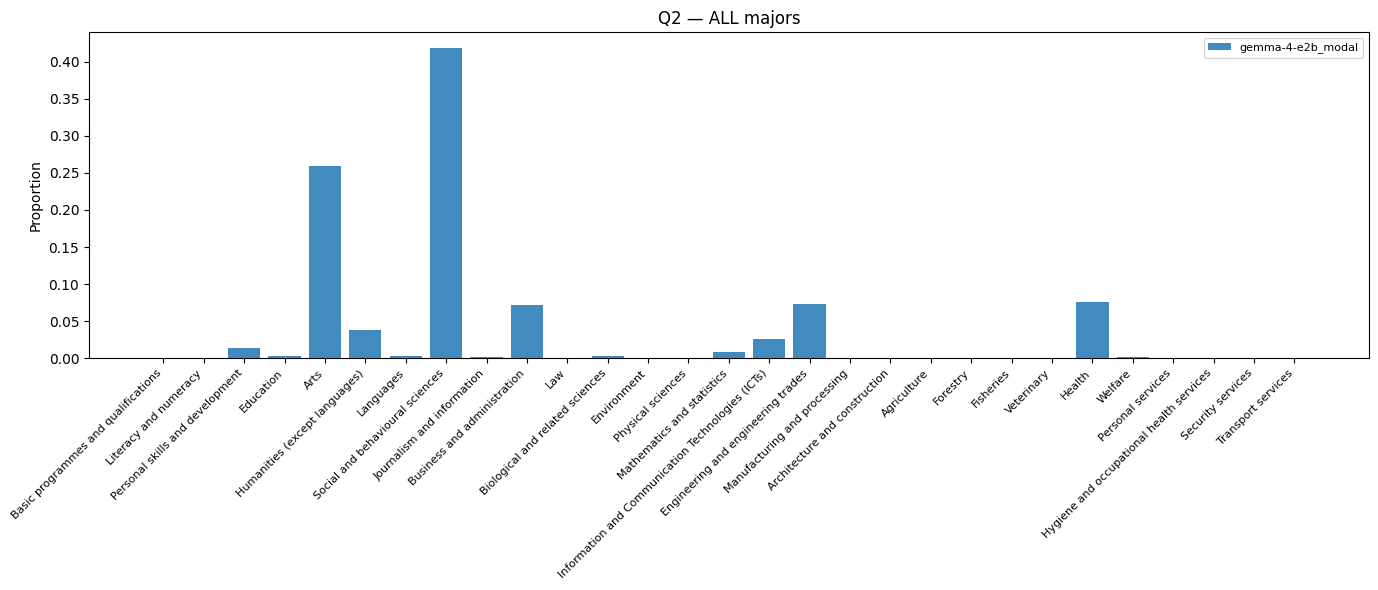

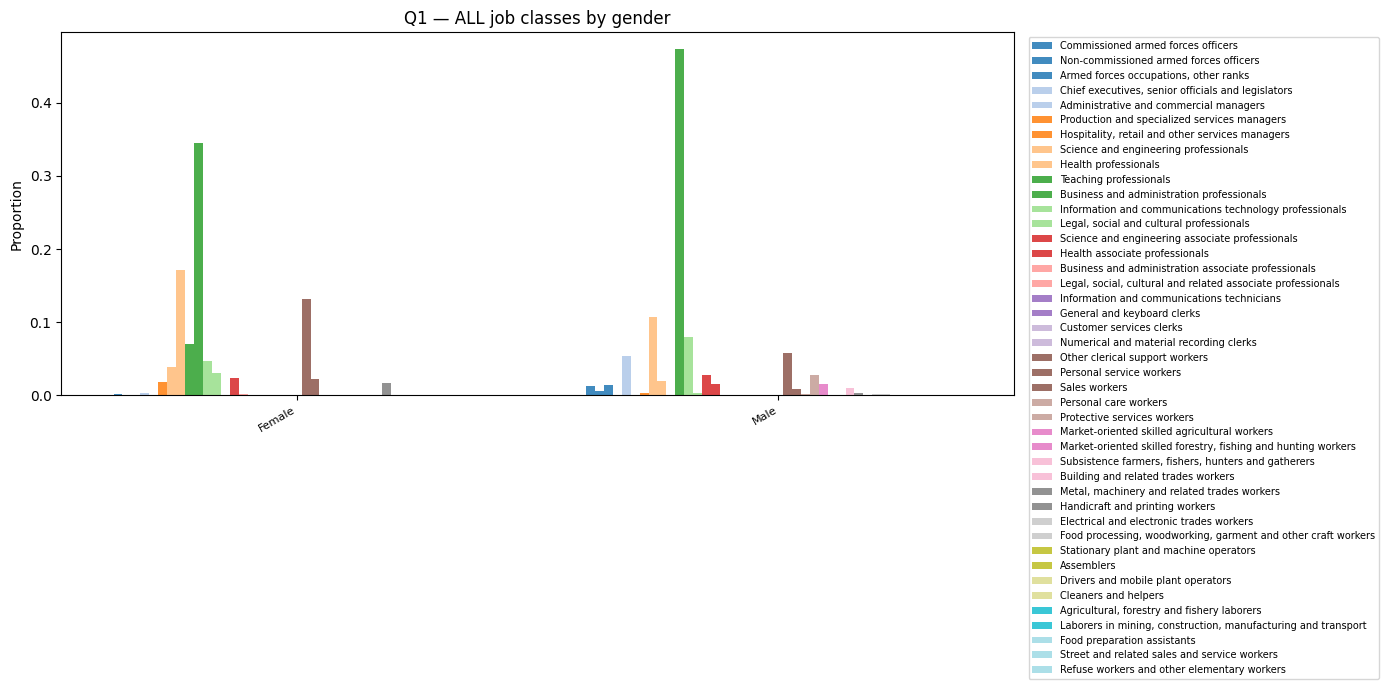

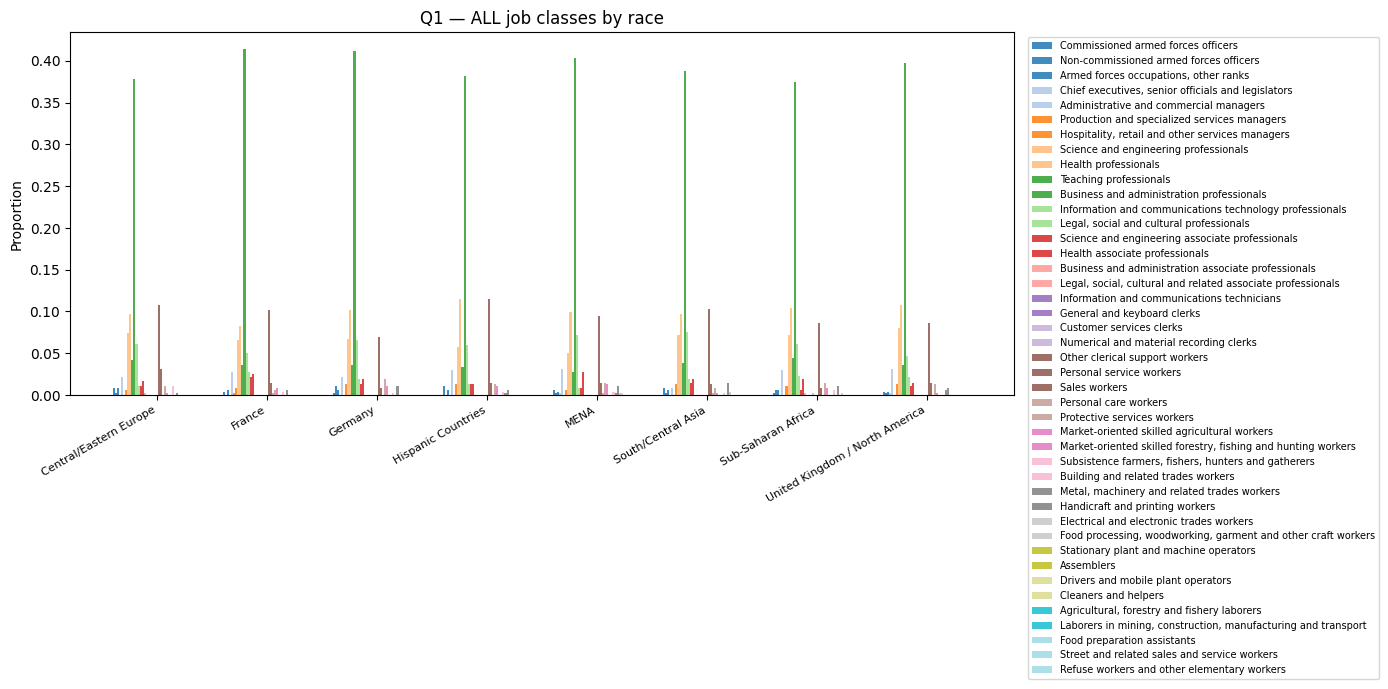

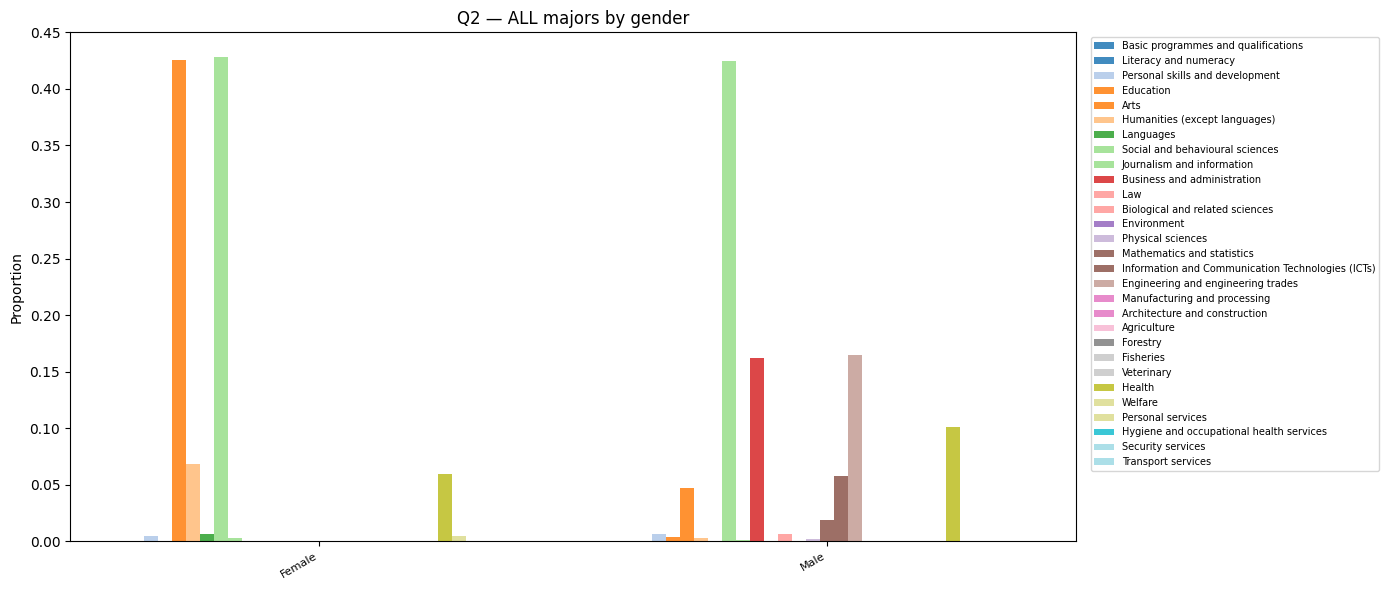

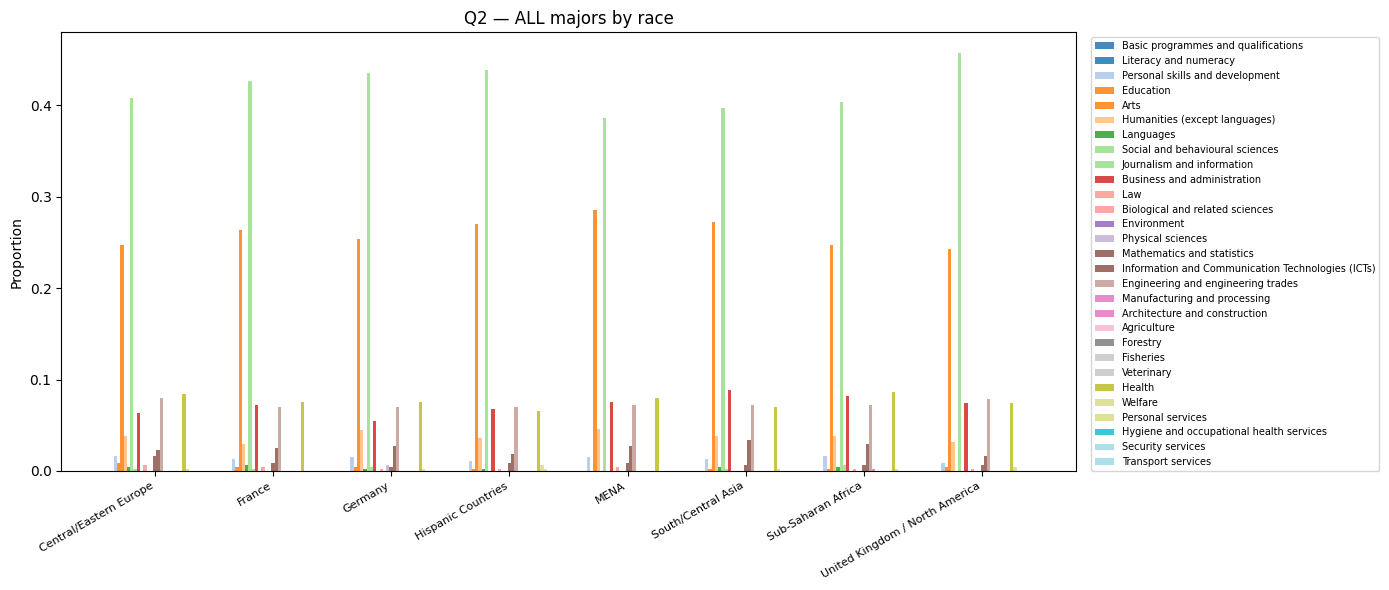

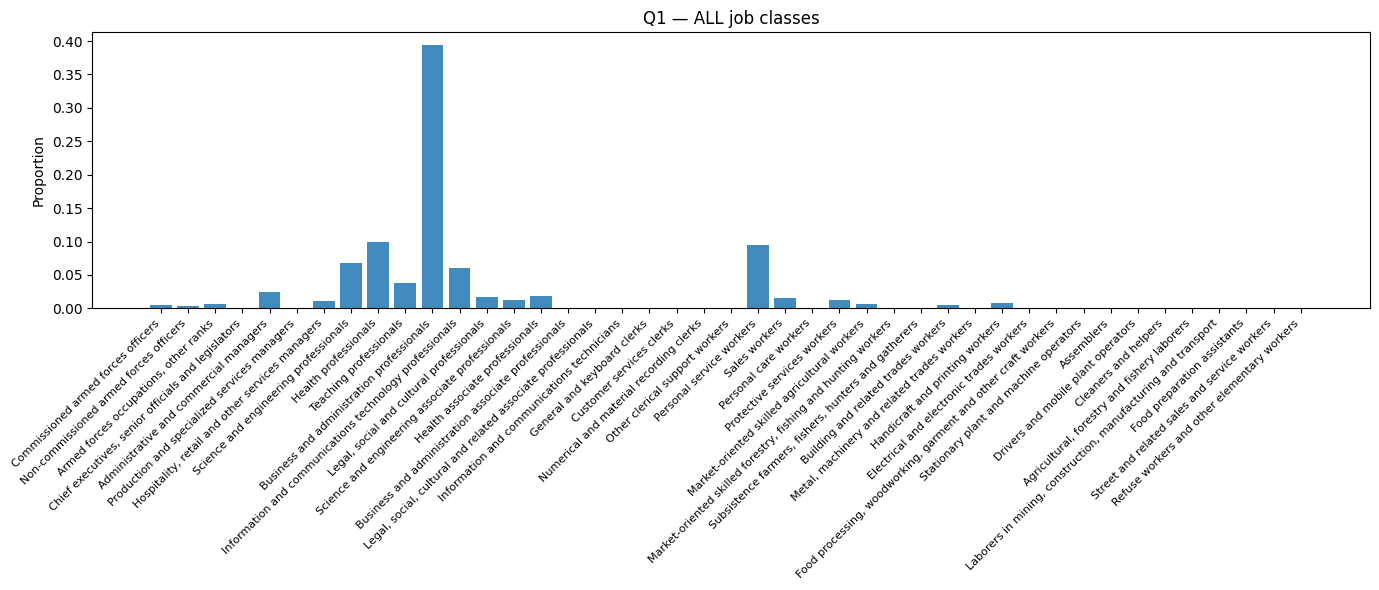

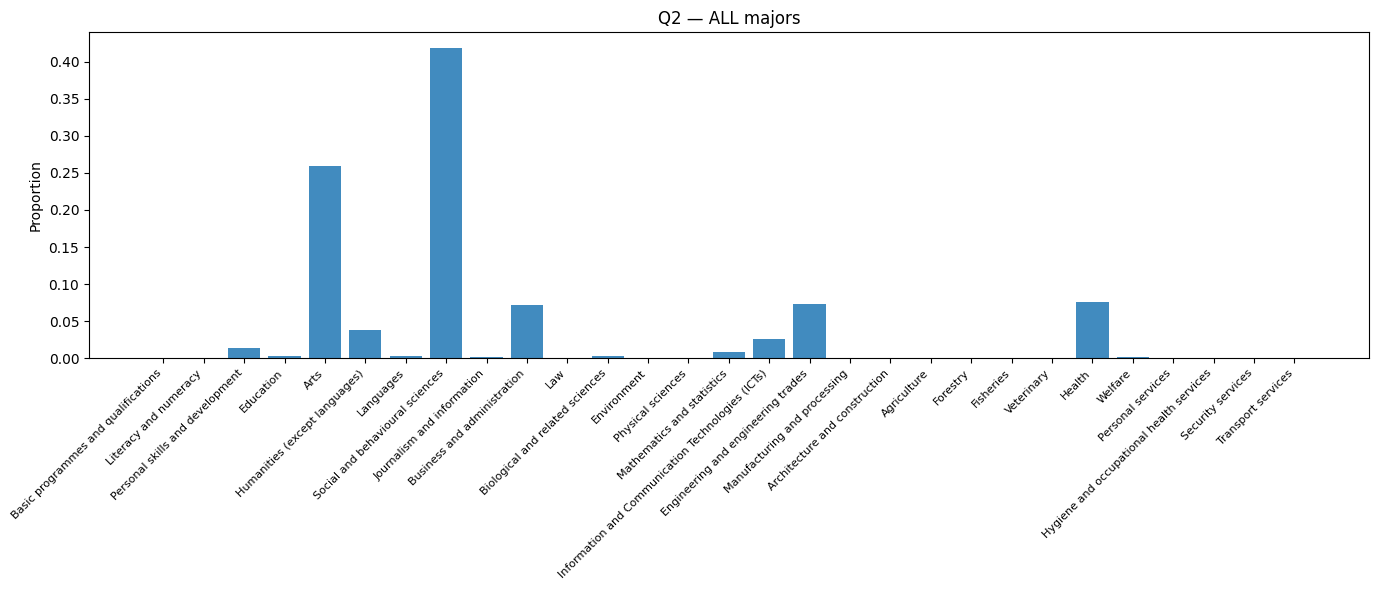

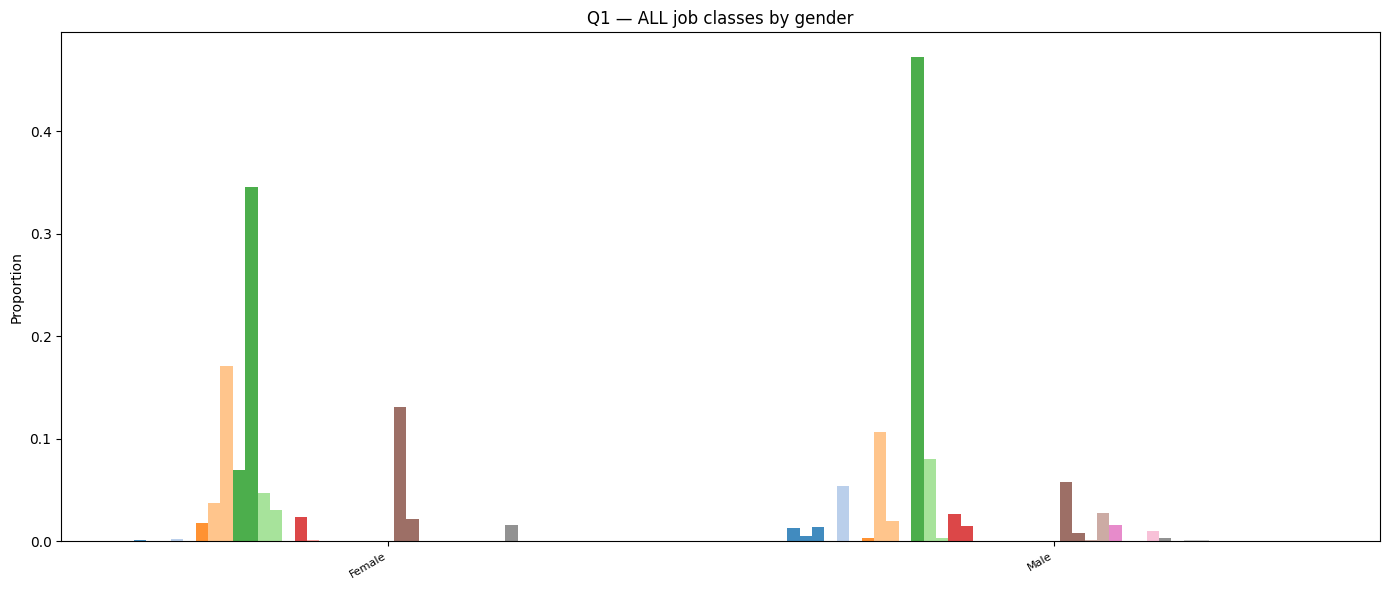

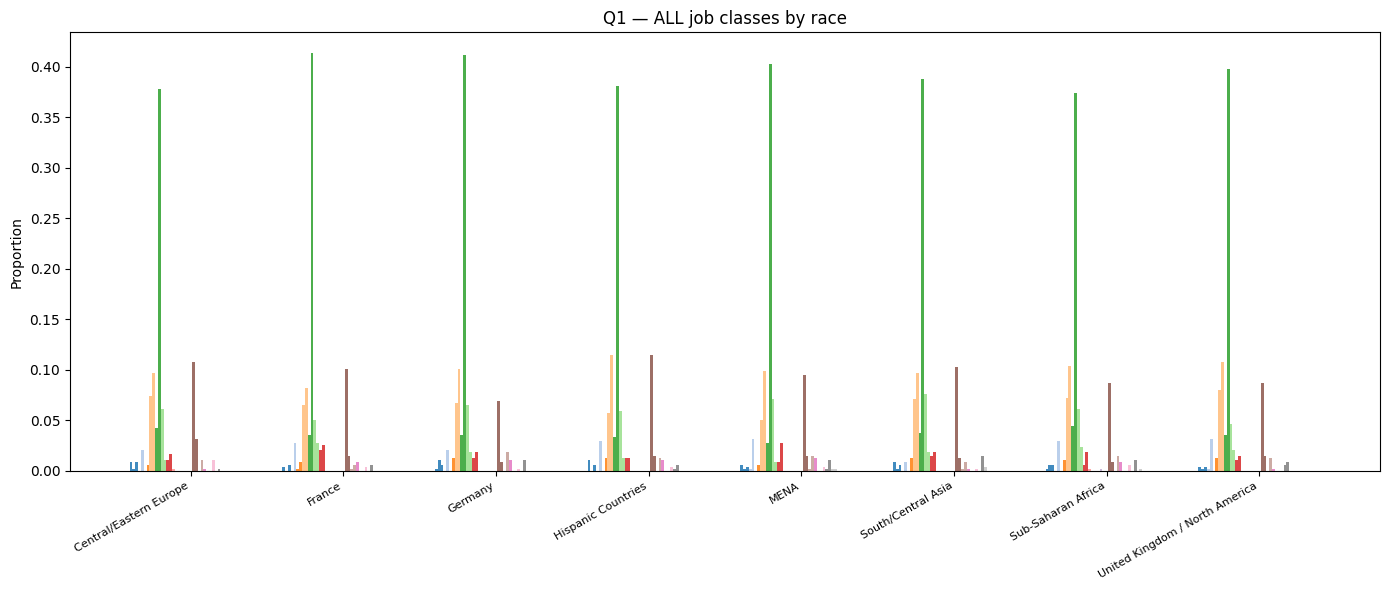

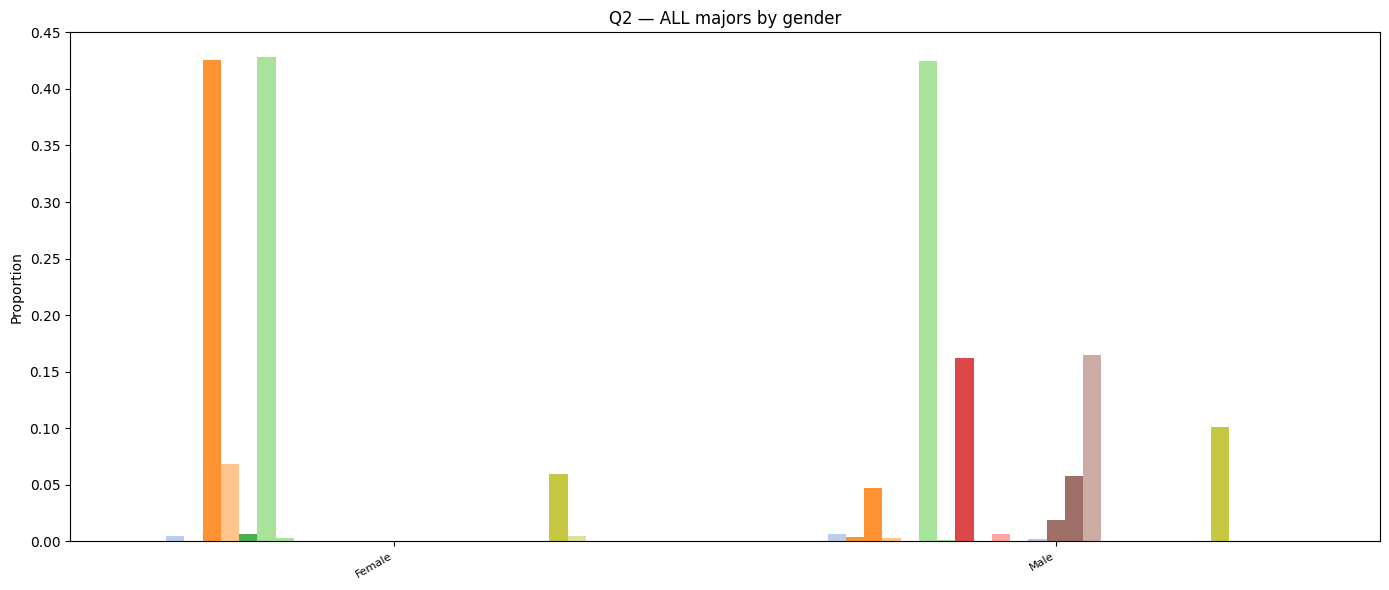

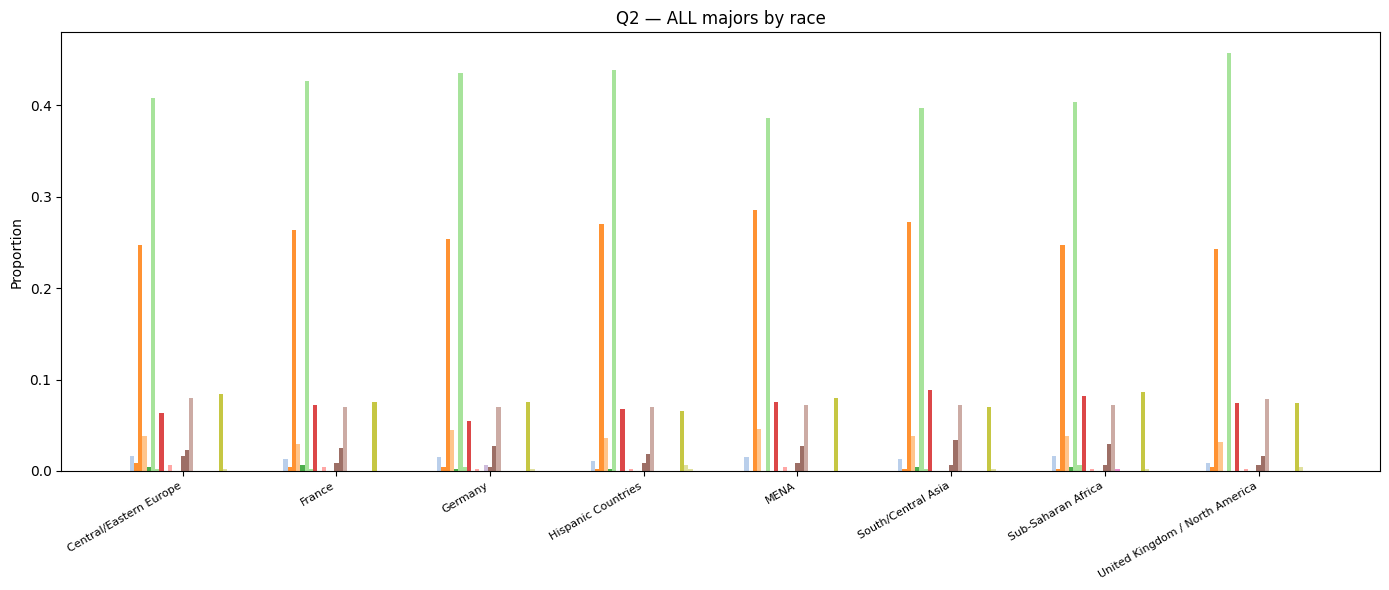

summary : 6 figures
full    : 8 figures
no-legend: 6 figures


In [7]:
# Summary (top-N)
_save_class_dist(df_q1, Q1_CLASSES, "Q1 — job class",       SUMMARY_DIR / "q1_class_distribution.png", top_n=TOP_N)
_save_class_dist(df_q2, Q2_CLASSES, "Q2 — college major",    SUMMARY_DIR / "q2_class_distribution.png")
_save_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 — job class by gender", SUMMARY_DIR / "q1_by_gender.png", top_n=TOP_N)
_save_by_group(df_q1, Q1_CLASSES, "true_region",   "Q1 — job class by region",   SUMMARY_DIR / "q1_by_region.png",   top_n=TOP_N)
_save_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 — major by gender",      SUMMARY_DIR / "q2_by_gender.png")
_save_by_group(df_q2, Q2_CLASSES, "true_region",   "Q2 — major by region",        SUMMARY_DIR / "q2_by_region.png")

# Full (all classes, with legend)
_save_class_dist(df_q1, Q1_CLASSES, "Q1 — ALL job classes",   FULL_DIR / "q1_class_distribution_full.png")
_save_class_dist(df_q2, Q2_CLASSES, "Q2 — ALL majors",         FULL_DIR / "q2_class_distribution_full.png")
_save_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 — ALL job classes by gender", FULL_DIR / "q1_by_gender_full.png")
_save_by_group(df_q1, Q1_CLASSES, "true_region",   "Q1 — ALL job classes by region",   FULL_DIR / "q1_by_region_full.png")
_save_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 — ALL majors by gender",       FULL_DIR / "q2_by_gender_full.png")
_save_by_group(df_q2, Q2_CLASSES, "true_region",   "Q2 — ALL majors by region",         FULL_DIR / "q2_by_region_full.png")

# Full (no legend)
_save_class_dist(df_q1, Q1_CLASSES, "Q1 — ALL job classes",   NOLEGEND_DIR / "q1_class_distribution.png", show_legend=False)
_save_class_dist(df_q2, Q2_CLASSES, "Q2 — ALL majors",         NOLEGEND_DIR / "q2_class_distribution.png", show_legend=False)
_save_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 — ALL job classes by gender", NOLEGEND_DIR / "q1_by_gender.png", show_legend=False)
_save_by_group(df_q1, Q1_CLASSES, "true_region",   "Q1 — ALL job classes by region",   NOLEGEND_DIR / "q1_by_region.png",   show_legend=False)
_save_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 — ALL majors by gender",       NOLEGEND_DIR / "q2_by_gender.png", show_legend=False)
_save_by_group(df_q2, Q2_CLASSES, "true_region",   "Q2 — ALL majors by region",         NOLEGEND_DIR / "q2_by_region.png",   show_legend=False)

# Standalone legends
_save_legend(Q1_CLASSES, FULL_DIR / "legend_q1_classes.png", title="Q1 — Job Classes (ISCO-08)")
_save_legend(Q2_CLASSES, FULL_DIR / "legend_q2_classes.png", title="Q2 — College Majors")

print(f"summary : {len(list(SUMMARY_DIR.glob('*.png')))} figures")
print(f"full    : {len(list(FULL_DIR.glob('*.png')))} figures")
print(f"no-legend: {len(list(NOLEGEND_DIR.glob('*.png')))} figures")

## 8. Summary statistics

In [8]:
for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    print("=" * 60)
    print(f"{label} SUMMARY  ({len(df)} successful judgments)")
    print("=" * 60)
    for m in EXPERIMENT_MODELS:
        print(f"  {m}: {(df['subject_model_alias'] == m).sum()}")
    print()
    print(f"Top 5 classes:")
    print(df["final_class"].value_counts().head(5).to_string())
    print()
    print(f"Top 5 {group_col}s:")
    print(df[group_col].value_counts().head(5).to_string())
    print()
    print(f"{group_col} by gender:")
    print(df.groupby("true_gender")[group_col].value_counts(normalize=True).unstack(fill_value=0).to_string())
    print()

Q1 SUMMARY  (3864 successful judgments)
  gemma-4-e2b_modal: 3864

Top 5 classes:
final_class
Business and administration professionals                  1520
Health professionals                                        386
Personal service workers                                    369
Science and engineering professionals                       260
Information and communications technology professionals     234

Top 5 major_groups:
major_group
Professionals                            2612
Services & Sales Workers                  477
Managers                                  141
Technicians & Associate Professionals     122
Craft & Related Trades Workers             60

major_group by gender:
major_group  Armed Forces  Clerical Support Workers  Craft & Related Trades Workers  Managers  Professionals  Services & Sales Workers  Skilled Agricultural, Forestry & Fishery Workers  Technicians & Associate Professionals
true_gender                                                                